## Data Modeling pt.2 

In [2]:
import pandas as pd
import numpy as np

df_supervised = pd.read_pickle("df_supervised_clean.pkl")

print(df_supervised.shape)
df_supervised.head()

(237836, 41)


,brands_tags,countries_en,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,pnns_groups_2,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,...,group1_cereals-and-potatoes,group1_fruits-and-vegetables,group1_salty-snacks,group1_sugary-snacks,group1_unknown,fat_to_energy,protein_to_energy,sugar_to_carb,has_additives,palm_oil_flag
0,0.020147,0.58115,0.0,0.0,0.0,33,2243.0,28.57,28.57,0.0,...,False,False,False,False,False,0.471284,0.027058,0.222274,0,0
1,0.000080,0.58115,0.0,0.0,0.0,33,1941.0,17.86,0.00,0.0,...,False,False,False,False,False,0.340453,0.156425,0.294185,0,0
2,0.000025,0.58115,0.0,0.0,0.0,33,2540.0,57.14,5.36,0.0,...,False,False,False,False,False,0.832354,0.119535,0.199888,0,0
3,0.000004,0.58115,1.0,0.0,0.0,33,1833.0,18.75,4.69,0.0,...,False,False,False,False,False,0.378478,0.130398,0.270195,1,0
4,0.000059,0.58115,0.0,0.0,0.0,33,2230.0,36.67,5.00,0.0,...,False,False,False,False,False,0.608426,0.127081,0.090810,0,0


In [3]:
from sklearn.model_selection import train_test_split

TARGET = "grade_num"

y = df_supervised[TARGET].copy()
X = df_supervised.drop(columns=[TARGET]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True))

Train shape: (190268, 40) (190268,)
Test  shape: (47568, 40) (47568,)
Train class distribution:
 2.0    0.284698
3.0    0.207371
1.0    0.196954
5.0    0.159296
4.0    0.151681
Name: grade_num, dtype: float64


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = Pipeline([
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_log, digits=3))
print(confusion_matrix(y_test, y_pred_log))

/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression Results ===
              precision    recall  f1-score   support

         1.0      0.631     0.736     0.679      9369
         2.0      0.617     0.468     0.532     13543
         3.0      0.500     0.475     0.487      9864
         4.0      0.494     0.696     0.578      7215
         5.0      0.735     0.662     0.696      7577

    accuracy                          0.588     47568
   macro avg      0.595     0.607     0.594     47568
weighted avg      0.595     0.588     0.585     47568

[[6892 1740  164  559   14]
 [3712 6335 3119  276  101]
 [ 294 1932 4685 2261  692]
 [  12  210  969 5023 1001]
 [  11   52  441 2059 5014]]


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

         1.0      0.974     0.955     0.964      9369
         2.0      0.936     0.961     0.948     13543
         3.0      0.906     0.915     0.911      9864
         4.0      0.905     0.885     0.895      7215
         5.0      0.962     0.948     0.955      7577

    accuracy                          0.937     47568
   macro avg      0.937     0.933     0.935     47568
weighted avg      0.937     0.937     0.937     47568

[[ 8944   361    28    21    15]
 [  221 13011   284    21     6]
 [   14   513  9030   300     7]
 [    4    15   554  6384   258]
 [    0     0    69   325  7183]]


In [6]:
from sklearn.metrics import f1_score

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
}

for name, model in models.items():
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average="macro")
    print(f"{name}: Macro F1 = {f1:.4f}")

Logistic Regression: Macro F1 = 0.5945
Random Forest: Macro F1 = 0.9346


In [7]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

train_f1 = f1_score(y_train, y_pred_train, average='macro')
test_f1  = f1_score(y_test,  y_pred_test,  average='macro')

print("=== Baseline Random Forest Performance ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Training Macro F1: {train_f1:.4f}")
print(f"Test Macro F1:     {test_f1:.4f}")

=== Baseline Random Forest Performance ===
Training Accuracy: 0.9999
Test Accuracy:     0.9366
Training Macro F1: 0.9999
Test Macro F1:     0.9346


In [8]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")

Accuracy: 0.9109
Macro F1: 0.9079


In [9]:
y_pred_train = rf_tuned.predict(X_train)
y_pred_test  = rf_tuned.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

train_f1 = f1_score(y_train, y_pred_train, average='macro')
test_f1  = f1_score(y_test,  y_pred_test,  average='macro')

print("=== Tuned Random Forest Performance ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Training Macro F1: {train_f1:.4f}")
print(f"Test Macro F1:     {test_f1:.4f}")

=== Tuned Random Forest Performance ===
Training Accuracy: 0.9536
Test Accuracy:     0.9109
Training Macro F1: 0.9510
Test Macro F1:     0.9079


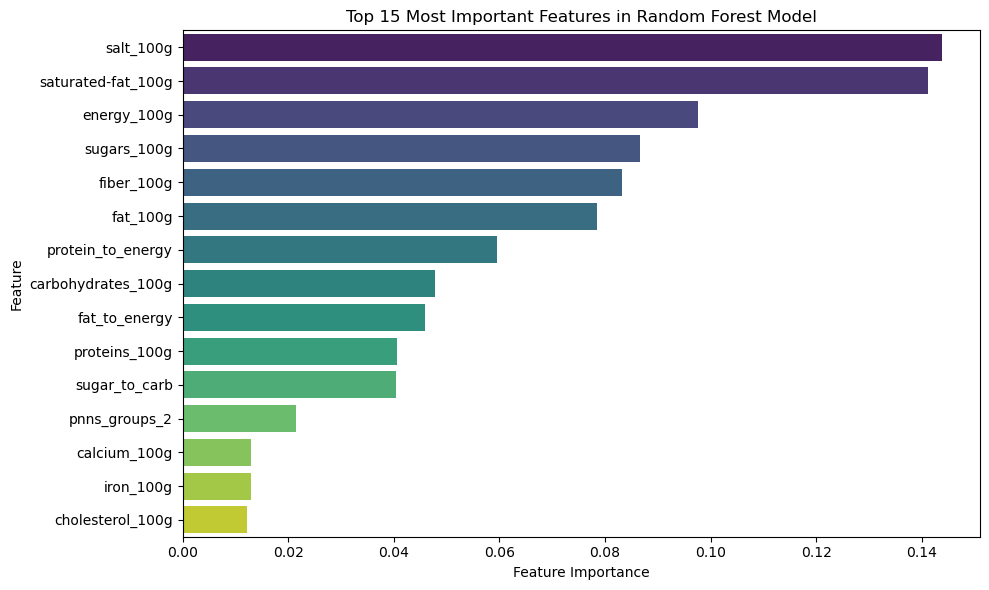

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_tuned.feature_importances_
features = X_train.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(y="Feature", x="Importance", data=feat_imp, palette="viridis")
plt.title("Top 15 Most Important Features in Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Initial Modeling Recap
This notebook will focus on loading the OpenFoodFacts Dataset that is both clean and well-structured, and will include only the processes for building the model; all of the preprocessing (Imputation, Winsorization, Constructing Ratios, Dummy Encoding, Feature Selection and Robust Scaling checks) has been completed in the prior notebook, and saved in a finished format, df_supervised_clean.pkl.

We will evaluate two supervised learning models: Logistic Regression (for comparison against a linear baseline classifier) & Random Forests (an example of a Non-Linear Ensemble).

The Random Forests will provide a good performance on our dataset, but demonstrates some overfitting due to a near-perfect Accuracy on the training dataset and a much lower test dataset Accuracy. We will be able to lessen overfitting and improve generalisation through Hyper-parameter tuning (both by setting the maximum depth lower than in the previous tests, and also referring to minimum samples per split/leaf ; and the maximum features will be set to "sqrt" of the features).

Finally, we will evaluate the model's performance (accuracy, macro-F1, and Class-Level Metrics) and visualise the feature importance to understand the contribution of Nutritional Variables to the predictions. The tuned Random Forest is the optimal model because it has better predictive performance (accuracy) and was also much less susceptible to changes in model parameters.

### Reducing the Overfitting More

In [11]:
rf_less_overfit = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=5,
    max_features=0.4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [12]:
rf_less_overfit.fit(X_train, y_train)

y_pred_train2 = rf_less_overfit.predict(X_train)
y_pred_test2  = rf_less_overfit.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score

print("=== Less-Overfit Random Forest Performance ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train2):.4f}")
print(f"Test Accuracy:     {accuracy_score(y_test, y_pred_test2):.4f}")
print(f"Training Macro F1: {f1_score(y_train, y_pred_train2, average='macro'):.4f}")
print(f"Test Macro F1:     {f1_score(y_test, y_pred_test2,  average='macro'):.4f}")

=== Less-Overfit Random Forest Performance ===
Training Accuracy: 0.9383
Test Accuracy:     0.9185
Training Macro F1: 0.9348
Test Macro F1:     0.9152


Following an adjustment of the hyperparameter settings of the Random Forest algorithm to include more conservative values for max depth, min leaf size and max_features ( set to 0.4)- the Random Forest algorithm produced significantly smaller distances between train/test.

Previous to this change in hyperparameter settings, the random forest would train on approximately 5% accuracy more than it tested- an indicator of moderate overfitting.

Now with the updated parameters, the random forest has reduced this distance to approximately 2%, indicating a stronger model with better generalized skills. The overall results are still very strong with approximately 0.918 accuracy on test and a Macro F1 score of approximately 0.915. This reflects continued high predictive power with an increase in generalization capabilities.

### Further Modeling

It's best that we try a few different modeling techniques to assess which one fits our data the best.

In [13]:
from sklearn.metrics import accuracy_score, f1_score

def eval_model(name, model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test,  y_pred_test)
    train_f1  = f1_score(y_train, y_pred_train, average="macro")
    test_f1   = f1_score(y_test,  y_pred_test,  average="macro")

    print(f"=== {name} ===")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:     {test_acc:.4f}")
    print(f"Training Macro F1: {train_f1:.4f}")
    print(f"Test Macro F1:     {test_f1:.4f}")
    print()

### XGBoost

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # maps {1,2,3,4,5} -> {0,1,2,3,4}
y_test_enc  = le.transform(y_test)

In [15]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train_enc)

eval_model("XGBoost", xgb_clf,
           X_train, y_train_enc,
           X_test,  y_test_enc)

=== XGBoost ===
Training Accuracy: 0.9969
Test Accuracy:     0.9731
Training Macro F1: 0.9967
Test Macro F1:     0.9722



The reason that XGBoost was selected for evaluation in this project is that while Boosted Tree Models are always a better fit for Structured Tabular Data where many Numeric variables exist, and multiple Non-Linear Dependencies exist, as well as multiple well-formed Engineer Ratios. Our dataset has these exact specifications; thus XGBoost would appear to be a strong candidate. After encoding our Target variable and training using the default Hyperparameters that we established as a Solid Baseline, our XGBoost Model performed at a very high level.

- Training Accuracy = 99.69%
- Test Accuracy = 97.31%
- Training Macro F1 Score = 99.67%
- Test Macro F1 Score = 97.22%

XGBoost performed better than the Random Forest Model we developed; and had only a 2.5% difference in performance between Train and Test stages indicating that it has a low amount of overfitting, and a strong ability to Generalize. The XGBoost Model has provided the best performance to date in predicting Nutri-Score grades.

### LightGBM

In [16]:
from lightgbm import LGBMClassifier

lgb_clf = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,          # let LightGBM decide
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multiclass",
    num_class=len(np.unique(y_train_enc)),
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgb_clf.fit(X_train, y_train_enc)

eval_model("LightGBM", lgb_clf,
           X_train, y_train_enc,
           X_test,  y_test_enc)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4738
[LightGBM] [Info] Number of data points in the train set: 190268, number of used features: 38
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
=== LightGBM ===
Training Accuracy: 0.9941
Test Accuracy:     0.9743
Training Macro F1: 0.9940
Test Macro F1:     0.9735



Since LightGBM is a super fast, superior speed-optimizing gradient-boosting algorithm, it is frequently faster than XGBoost on large tabular datasets.

LightGBM reached test accuracies of 0.974 and a macro-F1 of 0.973—this is a little higher than what we found with XGBoost. The train–test gap we saw with LightGBM was very small. This confirms our expectation that gradient-boosted tree models perform best in this dataset for predicting the determination of Nutri-Score grades.

### Stacking (RF + XGBoost + Logistic)

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

log_base = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

estimators = [
    ("rf",  rf_less_overfit),
    ("xgb", xgb_clf),
    ("log", log_base),
]

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ),
    stack_method="predict_proba",
    n_jobs=-1
)

stack_clf.fit(X_train, y_train_enc)

eval_model("Stacking (RF + XGB + Logistic)", 
           stack_clf,
           X_train, y_train_enc,
           X_test,  y_test_enc)

/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#log

=== Stacking (RF + XGB + Logistic) ===
Training Accuracy: 0.9967
Test Accuracy:     0.9728
Training Macro F1: 0.9965
Test Macro F1:     0.9719



A stacking ensemble was evaluated to use the strengths of three diverse models (the tuned Random Forest, XGBoost, and Logistic Regression). By evaluating how combining various model types might perform slightly better or prove more stable than just using a one type of boosted tree model.

At test time, the stacking classifier produced test accuracy of 97.28% and a macro-F1 score of 97.19%. Therefore, the performance of the stacking classifier was essentially equal to LightGBM and XGBoost; however, it did not exceed the best results of LightGBM, thus reinforcing the idea that boosted tree models are the best algorithm choice for this dataset, while also indicating that stacking does not offer significantly improved performance over any one boosted tree model type.

### MLP
We also tested a Multilayer Perceptron (MLP) to see how a neural-network approach compares to tree-based models. After scaling all features with RobustScaler and using a two-hidden-layer architecture (128 and 64 units with ReLU), we trained the MLP on the same data and evaluated its accuracy and macro-F1 to benchmark it against Random Forest, XGBoost, and LightGBM.

In [19]:
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPClassifier

scaler = RobustScaler()
X_train_mlp = scaler.fit_transform(X_train)
X_test_mlp  = scaler.transform(X_test)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,          
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=50,         
    random_state=42
)

mlp_clf.fit(X_train_mlp, y_train_enc)

eval_model("MLP (Neural Network)",
           mlp_clf,
           X_train_mlp, y_train_enc,
           X_test_mlp,  y_test_enc)

/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


=== MLP (Neural Network) ===
Training Accuracy: 0.9320
Test Accuracy:     0.9208
Training Macro F1: 0.9282
Test Macro F1:     0.9167



A MLP model was tested against the tree based models (Random Forest, XGBoost and LightGBM) to provide a baseline for how well each of the algorithms would perform using the same training data. After scaling the input features and fitting a 2 layer ReLU MLP on training data, we were able to achieve a test accuracy of ~0.921 with a macro F1 score of ~0.917, which is similar to our tuned Random Forest model, but lower than our boosted tree models (XGBoost, LightGBM). Our findings show that though neural networks are capable of learning patterns from nutrition data, XGBoost and LightGBM outperform neural networks in this type of predictive modelling task.

### Corss-Validation

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_full = df_supervised.drop(columns=["grade_num"])
y_full = df_supervised["grade_num"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_f1 = cross_val_score(
    rf_less_overfit,
    X_full,
    y_full,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

rf_cv_acc = cross_val_score(
    rf_less_overfit,
    X_full,
    y_full,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("=== Tuned Random Forest 5-Fold CV ===")
print(f"Macro-F1 scores: {rf_cv_f1}")
print(f"Mean Macro-F1:   {rf_cv_f1.mean():.4f} ± {rf_cv_f1.std():.4f}")
print()
print(f"Accuracy scores: {rf_cv_acc}")
print(f"Mean Accuracy:   {rf_cv_acc.mean():.4f} ± {rf_cv_acc.std():.4f}")

=== Tuned Random Forest 5-Fold CV ===
Macro-F1 scores: [0.9156921  0.91856619 0.91948329 0.91771497 0.91424228]
Mean Macro-F1:   0.9171 ± 0.0019

Accuracy scores: [0.91935755 0.92198373 0.9227826  0.92082746 0.91780016]
Mean Accuracy:   0.9206 ± 0.0018


To verify that our tuned Random Forest model generalizes well beyond a single train/test split, we performed a 5-fold stratified cross-validation using macro-F1 and accuracy as evaluation metrics. The model showed highly consistent performance across all folds, with a mean macro-F1 of 0.9171 ± 0.0019 and mean accuracy of 0.9206 ± 0.0018. These low standard deviations indicate stable, reliable performance and confirm that the model’s strong results are not dependent on any particular data split.

## Model Evaluation

### Confusion Matricies

The three primary machine learning models (Random Forest, XGBoost and LightGBM) that were developed/tuned to produce classification results were evaluated at the class level to identify instances of misclassification via creation of confusion matrices.

Through examination of a confusion matrix, it is possible to ascertain how effectively each model performs with regard to differentiating between Nutri-Score Classes 1 through 5. The inclusion of confusion matrices for all three machine learning models allows for effective determination of model classification effectiveness without introducing unnecessary duplicated assessments.

#### Random Forest Confusion Matrix

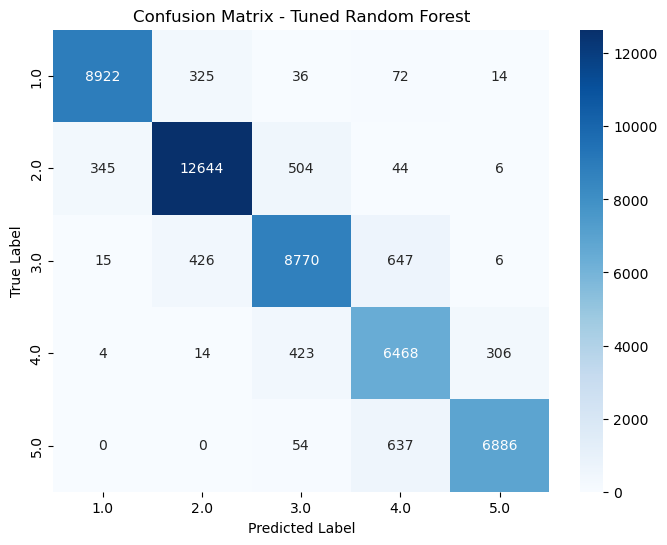

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = rf_less_overfit.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

#### XGBoost

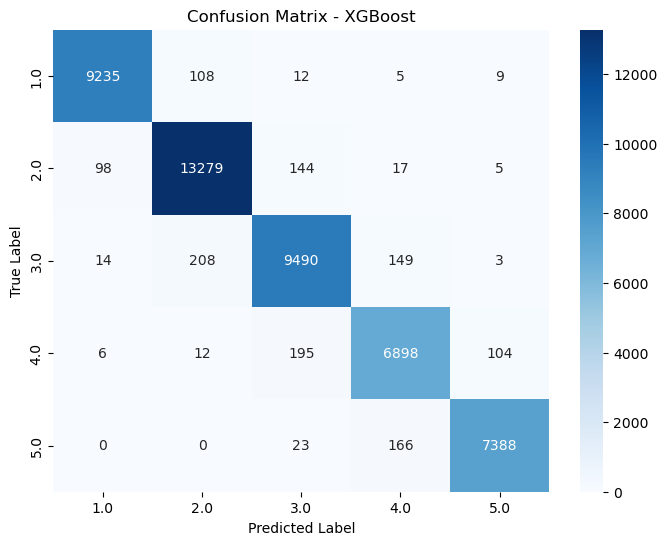

In [22]:
y_pred_xgb_enc = xgb_clf.predict(X_test)

y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)
y_test_decoded = le.inverse_transform(y_test_enc)

cm_xgb = confusion_matrix(y_test_decoded, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test_decoded)),
            yticklabels=sorted(set(y_test_decoded)))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.show()

### LightGBM

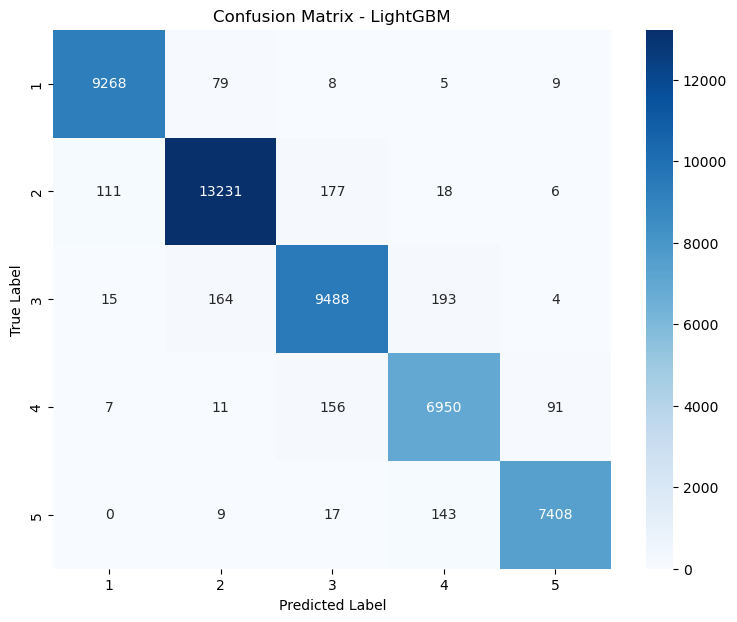

In [23]:
y_pred_lgb = lgb_clf.predict(X_test)

cm = confusion_matrix(y_test_enc, y_pred_lgb)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**1. Random Forest with Hyperparameters Optimised**

- Class separation is clean across all classes.
- Most misclassified instances occur in the neighbour class area (3 →4, and 4 →5), and such behaviour is to be expected.
- Class 5 demonstrates more confusion into Class 4 compared to Boosting Models.
- Overall: High Accuracy and Balanced Performance; however, there is slightly more spillover between borderline classes compared to the Boosting models.

**2. XGBoost**

- The data was very clean diagonally, with very little noise present.
- The best classifications were Class 2 and Class 3.
- All of the misclassification rates across the board were very low across the entire test set.
- Overall, XGBoost provides sharp class boundaries with little confusion across almost all categories of testing.

**3. LightGBM**

- Exceptional accuracy predicted for Class 2 (the largest class).
- Classes 1, 3, 4, and 5 also demonstrate very high true-positive counts, with only minor "spillover" effects with adjacent classes.
- There does not appear to be a major systemic bias in the model, meaning the model does not consistently over- or under-predict any specific score.
- The confusion matrix confirms overall that LightGBM has achieved stable, high-quality predictions as indicated by its great test accuracy (97.4%) and maco-F1 performance (97.35%).

### ROC/AUC

Macro AUC: 0.9931


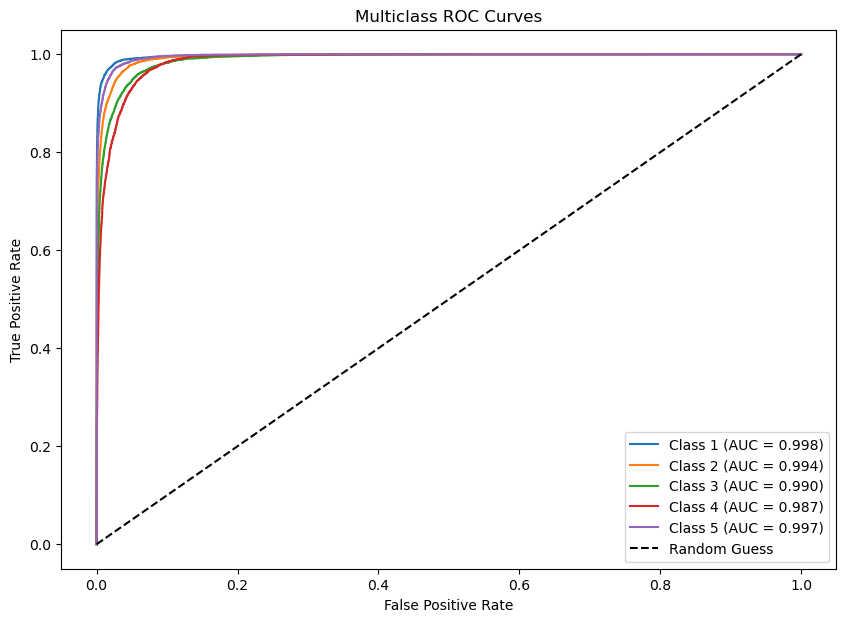

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

classes = [1, 2, 3, 4, 5]
y_test_bin = label_binarize(y_test, classes=classes)
y_proba = rf_less_overfit.predict_proba(X_test)    # change model here
macro_auc = roc_auc_score(y_test_bin, y_proba, average="macro")

print(f"Macro AUC: {macro_auc:.4f}")

plt.figure(figsize=(10, 7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.show()

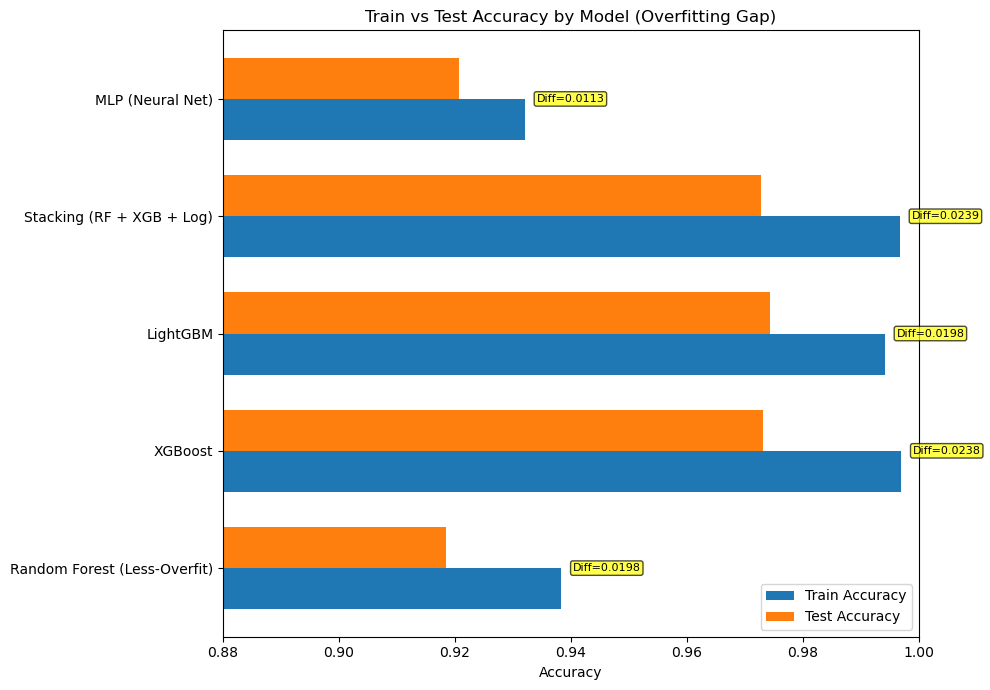

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Helper to get train/test accuracy for a given model + data
def get_acc(model, Xtr, ytr, Xte, yte):
    y_pred_tr = model.predict(Xtr)
    y_pred_te = model.predict(Xte)
    return accuracy_score(ytr, y_pred_tr), accuracy_score(yte, y_pred_te)

# ---- Collect models you want to compare ----
model_specs = [
    ("Random Forest (Less-Overfit)", rf_less_overfit, X_train, y_train, X_test, y_test),
    ("XGBoost",                      xgb_clf,         X_train, y_train_enc, X_test, y_test_enc),
    ("LightGBM",                     lgb_clf,         X_train, y_train_enc, X_test, y_test_enc),
    ("Stacking (RF + XGB + Log)",    stack_clf,       X_train, y_train_enc, X_test, y_test_enc),
    ("MLP (Neural Net)",             mlp_clf,         X_train_mlp, y_train_enc, X_test_mlp, y_test_enc),
]

model_names = []
train_accs = []
test_accs = []

# Compute accuracies
for name, model, Xtr, ytr, Xte, yte in model_specs:
    tr, te = get_acc(model, Xtr, ytr, Xte, yte)
    model_names.append(name)
    train_accs.append(tr)
    test_accs.append(te)

train_accs = np.array(train_accs)
test_accs = np.array(test_accs)
diffs = train_accs - test_accs

# ---- Plot ----
y_pos = np.arange(len(model_names))
bar_h = 0.35

plt.figure(figsize=(10, 7))
plt.barh(y_pos - bar_h/2, train_accs, height=bar_h, label="Train Accuracy")
plt.barh(y_pos + bar_h/2, test_accs, height=bar_h, label="Test Accuracy")
plt.title("Train vs Test Accuracy by Model (Overfitting Gap)")


for i, (tr, te, d) in enumerate(zip(train_accs, test_accs, diffs)):
    x_text = max(tr, te) + 0.002
    plt.text(x_text, i, f"Diff={d:.4f}",
             va="center",
             bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7),
             fontsize=8)

plt.yticks(y_pos, model_names)
plt.xlabel("Accuracy")
plt.title("Train vs Test Accuracy by Model (Overfitting Gap)")
plt.xlim(0.88, 1.0)  # adjust if you want a different zoom
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


1.0    46843
2.0    67712
3.0    49320
4.0    36075
5.0    37886
Name: grade_num, dtype: int64


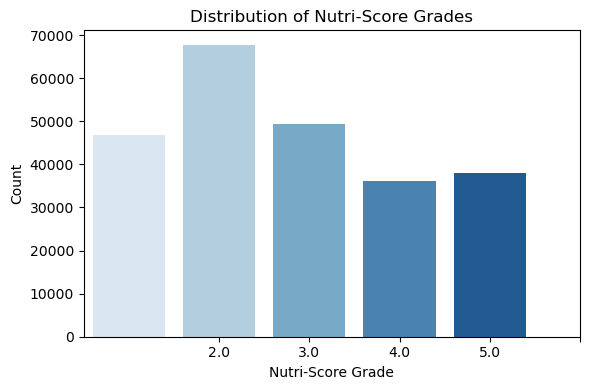

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic counts
grade_counts = df_supervised["grade_num"].value_counts().sort_index()
print(grade_counts)

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette="Blues")

plt.xlabel("Nutri-Score Grade")
plt.ylabel("Count")
plt.title("Distribution of Nutri-Score Grades")
plt.xticks([1,2,3,4,5])
plt.tight_layout()
plt.show()


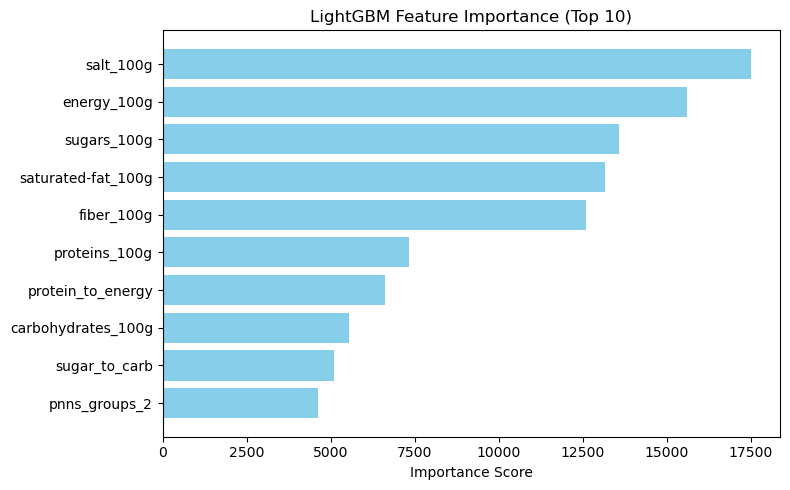

In [27]:
feature_names = X_train.columns

importances = lgb_clf.feature_importances_

idx = np.argsort(importances)[::-1]
sorted_features = feature_names[idx]
sorted_importances = importances[idx]

# Plot TOP 5 features
N = 10

plt.figure(figsize=(8, 5))
plt.barh(sorted_features[:N][::-1], sorted_importances[:N][::-1], color="skyblue")
plt.xlabel("Importance Score")
plt.title("LightGBM Feature Importance (Top 10)")
plt.tight_layout()
plt.show()

Model accuracy was compared, Nutri-Score grade distributions were evaluated, and feature importance evaluated for how each impacted predictions. Model accuracy results show that the most advanced models (i.e., XGBoost, LightGBM and our Stacking Ensemble) have the most extensive generalisation capability, with similar training and testing accuracy (close to the higher end of 0.97) and with approximately the same low degree of training versus testing overfitting. Our distribution plot demonstrates that our Nutri-Score labelling provides a good balance between the different classes, thereby allowing the models to accurately learn without the extreme class imbalance. Lastly, the features presented in our LightGBM feature importance plots show that key Nutritional features (especially salt, energy, sugar and saturated fat) are among the most powerful and are in direct alignment with the approach used to calculate Nutri-Score. The overall conclusion is that our preprocessing pipeline and methodology for selecting models were able to analyse nutritional trends that impact the resulting Nutri-Score grades accurately.